In [1]:
%%javascript
IPython.notebook.events.off('checkpoint_created.Notebook');
IPython.notebook.events.off('notebook_saved.Notebook');

<IPython.core.display.Javascript object>

# Imports
Import packages that will be used to analyze and plot data

In [2]:
%load_ext autoreload
%autoreload 2
from functions import split_splits_by_task_type, get_vals2, get_vals_foil_type, chunk_data

import numpy as np
import pandas as pd
import os
import copy
from tqdm.notebook import tqdm
from scipy.ndimage.interpolation import shift

%matplotlib inline
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Define Paths and Functions
- define the path to data
- define a few convenience functions to arrange data

In [3]:
# read data
final_reinf_df_path = 'final_reinf_df.csv'
data = pd.read_csv(final_reinf_df_path)

In [4]:
# create dataframe groups: by animal and by session

by_animal = data.groupby('animal')
by_session = data.groupby('session_index')

# example usage: by_animal.get_group(NAME_OF_ANIMAL)
by_animal.get_group('ab14')

,pretrial_licks,outcomes,trial_types,lick_latencies,session_index,trial_index,stim_type,serial,animal,task_types
0,0,miss,reinf,NaN,0,0,target,ru,ab14,combined task
1,0,miss,reinf,NaN,0,1,target,ru,ab14,combined task
2,0,miss,reinf,NaN,0,2,target,ru,ab14,combined task
3,0,miss,reinf,NaN,0,3,target,ru,ab14,combined task
4,0,miss,reinf,NaN,0,4,target,ru,ab14,combined task
...,...,...,...,...,...,...,...,...,...,...
5495,0,hit,reinf,0.058,21,5755,target,ru,ab14,combined task
5496,0,fa,reinf,0.002,21,5756,foil,rd,ab14,combined task
5497,0,hit,reinf,0.082,21,5757,target,ru,ab14,combined task
5498,0,cr,reinf,NaN,21,5758,foil,rd,ab14,combined task


# Plotting basic metrics
- plot hit rate, false alarm rate, and overall accuracy rates
- plot false alarm rates by foil type

In [5]:
BLOCK_SIZE = 250 # group trials into blocks of 250 (arbitrary) so we can calculate rates/metrics over learning
TASK_TYPE = 'combined task' # only index 'combined task' sessions here
animals = list(data.animal.unique()) # list of animals in our dataset

chunked_data = []
for ANIMAL in animals:
    temp = by_animal.get_group(ANIMAL).groupby('task_types').get_group(TASK_TYPE) # stores data for ANIMAL by TASK_TYPE
    chunk = list(chunk_data(temp, BLOCK_SIZE)) # split data for specific ANIMAL into chunks of 250 (BLOCK_SIZE)
    chunked_data.append(chunk) # append chunks to list for easy processing later

In [6]:
# in blockwise-fashion, compute hit rate (hr), false alarm rate (fa), and accuracy (acc)

ANIMAL_SELECT = None # If none, then returns average of all animals
hr, fa, acc, hr_sem, fa_sem, acc_sem = get_vals2(chunked_data, ANIMAL_SELECT)
_, foil_fa, _, _, foil_fa_sem, _ = get_vals_foil_type(chunked_data, ANIMAL_SELECT)

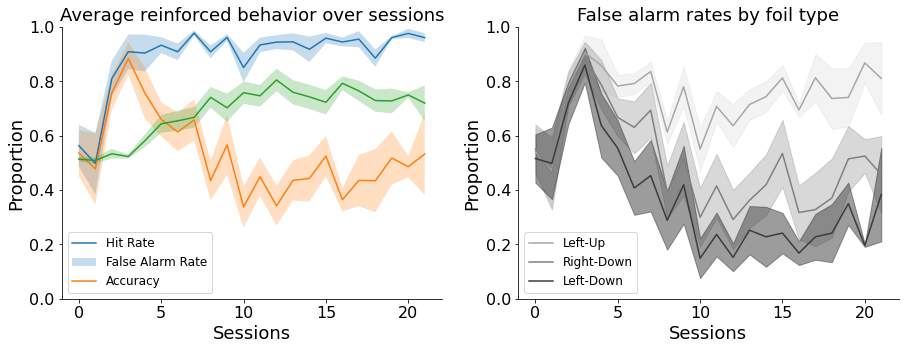

In [7]:
# plot basic metrics over time 
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

#### plot hit rates, false alarm rates, and accuracy ####

ax[0].plot(hr, c='C0'); ax[0].fill_between(np.arange(0, len(hr_sem)), hr-hr_sem, hr+hr_sem, alpha=0.25)
ax[0].plot(fa, c='C1'); ax[0].fill_between(np.arange(0, len(fa_sem)), fa-fa_sem, fa+fa_sem, alpha=0.25)
ax[0].plot(acc, c='C2'); ax[0].fill_between(np.arange(0, len(acc_sem)), acc-acc_sem, acc+acc_sem, alpha=0.25)

#ax[0].set_xticks(np.arange(0, len(hr)))


ax[0].set_xlabel('Sessions', fontsize=18)
ax[0].set_ylabel('Proportion', fontsize=18)
ax[0].set_title('Average reinforced behavior over sessions', fontsize=18)

ax[0].set_ylim(0, 1.0)
ax[0].tick_params(axis='both', which='major', labelsize=16)

ax[0].spines['right'].set_visible(False)
ax[0].spines['top'].set_visible(False)
ax[0].legend(['Hit Rate', 'False Alarm Rate', 'Accuracy'], loc='lower left', fontsize=12, markerscale=2)



#### plot false alarm rates by foil type ####

ax[1].plot(foil_fa[:,2], c="#a7a7a7")
ax[1].plot(foil_fa[:,1], c="#808080")
ax[1].plot(foil_fa[:,3], c="#3b3b3b")

ax[1].fill_between(np.arange(0, len(foil_fa_sem)), foil_fa[:,2]-foil_fa_sem[:,2], 
                   foil_fa[:,2]+foil_fa_sem[:,2], alpha=0.2, color="#c5c5c5")
ax[1].fill_between(np.arange(0, len(foil_fa_sem)), foil_fa[:,1]-foil_fa_sem[:,1], 
                   foil_fa[:,1]+foil_fa_sem[:,1], alpha=0.3, color="#808080")
ax[1].fill_between(np.arange(0, len(foil_fa_sem)), foil_fa[:,3]-foil_fa_sem[:,3], 
                   foil_fa[:,3]+foil_fa_sem[:,3], alpha=0.5, color="#3b3b3b")

ax[1].set_xlabel('Sessions', fontsize=18)
ax[1].set_ylabel('Proportion', fontsize=18)
ax[1].set_title('False alarm rates by foil type', fontsize=18)

ax[1].set_ylim(0, 1.0)
ax[1].tick_params(axis='both', which='major', labelsize=16)

ax[1].spines['right'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[1].legend(['Left-Up', 'Right-Down', 'Left-Down'], loc='lower left', fontsize=12, markerscale=2)

# Decomposition performance
- plot performance on first two sessions of decomposition 

In [8]:
new_df = data[data.task_types == 'decomposition']
new_df['specific_task'] = np.zeros(len(new_df))

lrl = np.where(new_df.serial == 'LR-L')[0]
lrr = np.where(new_df.serial == 'LR-R')[0]
ru = np.where(new_df.serial == 'ru')[0]
rd = np.where(new_df.serial == 'rd')[0]

l_task_index = np.sort(np.concatenate((lrl, lrr)))
fd_task_index = np.sort(np.concatenate((ru, rd)))

new_df.loc[:, 'specific_task'].iloc[l_task_index] = np.repeat('localization', len(l_task_index))
new_df.loc[:, 'specific_task'].iloc[fd_task_index] = np.repeat('frequency_direction', len(fd_task_index))

C:\Users\AneeshBal\AppData\Local\Temp\ipykernel_18384\20044365.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['specific_task'] = np.zeros(len(new_df))
C:\Users\AneeshBal\AppData\Local\Temp\ipykernel_18384\20044365.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df.loc[:, 'specific_task'].iloc[l_task_index] = np.repeat('localization', len(l_task_index))
C:\Users\AneeshBal\AppData\Local\Temp\ipykernel_18384\20044365.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the document

In [9]:
new_df[new_df.animal == 'ab17']

,pretrial_licks,outcomes,trial_types,lick_latencies,session_index,trial_index,stim_type,serial,animal,task_types,specific_task
14500,0,hit,reinf,0.093,14,3660,target,LR-R,ab17,decomposition,localization
14501,16,hit,reinf,0.105,14,3661,target,LR-R,ab17,decomposition,localization
14502,3,hit,reinf,0.026,14,3662,target,LR-R,ab17,decomposition,localization
14503,0,hit,reinf,0.008,14,3663,target,LR-R,ab17,decomposition,localization
14504,0,hit,reinf,0.024,14,3664,target,LR-R,ab17,decomposition,localization
...,...,...,...,...,...,...,...,...,...,...,...
14995,0,miss,reinf,NaN,15,4175,target,LR-R,ab17,decomposition,localization
14996,0,miss,reinf,NaN,15,4176,target,LR-R,ab17,decomposition,localization
14997,0,cr,reinf,NaN,15,4177,foil,LR-L,ab17,decomposition,localization
14998,0,cr,reinf,NaN,15,4178,foil,LR-L,ab17,decomposition,localization


In [10]:
BLOCK_SIZE = 50 # group trials into blocks of 250 (arbitrary) so we can calculate rates/metrics over learning
LIMIT = 250
SPECIFIC_TASK = 'localization'
animals = list(new_df.animal.unique()) # list of animals in our dataset

loc_chunked_data = []
for ANIMAL in animals[0:]:
    temp = new_df[new_df.animal == ANIMAL].groupby('specific_task').get_group(SPECIFIC_TASK).iloc[0:LIMIT] # convenience
    chunk = list(chunk_data(temp, BLOCK_SIZE)) # split data for specific ANIMAL into chunks
    loc_chunked_data.append(chunk) # append chunks to list for easy processing later
    
SPECIFIC_TASK = 'frequency_direction'
fd_chunked_data = []
for ANIMAL in animals[0:]:
    temp = new_df[new_df.animal == ANIMAL].groupby('specific_task').get_group(SPECIFIC_TASK).iloc[0:LIMIT] # convenience
    chunk = list(chunk_data(temp, BLOCK_SIZE)) # split data for specific ANIMAL into chunks
    fd_chunked_data.append(chunk) # append chunks to list for easy processing later

In [11]:
hr1, fa1, acc1, hr_sem1, fa_sem1, acc_sem1 = get_vals2(loc_chunked_data)
hr2, fa2, acc2, hr_sem2, fa_sem2, acc_sem2 = get_vals2(fd_chunked_data)

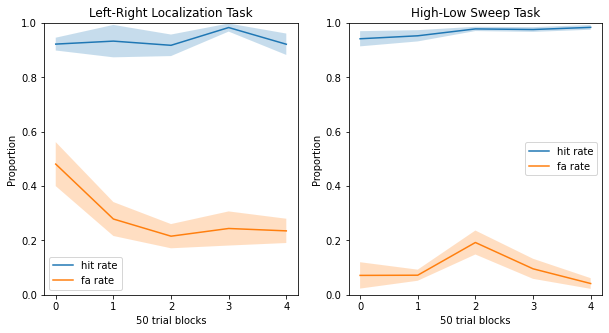

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(hr1)
ax[0].plot(fa1)
ax[0].fill_between(np.arange(0, len(hr1)), hr1-hr_sem1, hr1+hr_sem1, alpha=0.25)
ax[0].fill_between(np.arange(0, len(fa1)), fa1-fa_sem1, fa1+fa_sem1, alpha=0.25)

hr2 = hr2
hr_sem2 = hr_sem2
fa2 = fa2
fa_sem2 = fa_sem2
ax[1].plot(hr2)
ax[1].plot(fa2)
ax[1].fill_between(np.arange(0, len(hr2)), hr2-hr_sem2, hr2+hr_sem2, alpha=0.25)
ax[1].fill_between(np.arange(0, len(fa2)), fa2-fa_sem2, fa2+fa_sem2, alpha=0.25)

ax[0].set_ylim(0, 1.0)
ax[1].set_ylim(0, 1.0)

ax[0].set_ylabel('Proportion')
ax[0].set_xlabel('50 trial blocks')
ax[0].set_title('Left-Right Localization Task')
ax[0].legend(['hit rate', 'fa rate'])

ax[1].set_ylabel('Proportion')
ax[1].set_xlabel('50 trial blocks')
ax[1].set_title('High-Low Sweep Task')
ax[1].legend(['hit rate', 'fa rate'])